<a href="https://colab.research.google.com/github/YashwantkumarPolaki/CN-task/blob/main/NeuraMorphix_core.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('health_activity_data.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)



Shape: (1000, 16)

Columns:
['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Steps', 'Calories_Intake', 'Hours_of_Sleep', 'Heart_Rate', 'Blood_Pressure', 'Exercise_Hours_per_Week', 'Smoker', 'Alcohol_Consumption_per_Week', 'Diabetic', 'Heart_Disease']

First 3 rows:


,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No


In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = [
    'Age', 'BMI', 'Daily_Steps', 'Hours_of_Sleep',
    'Heart_Rate', 'Exercise_Hours_per_Week', 'Calories_Intake',
    'Weight_kg', 'Height_cm', 'Alcohol_Consumption_per_Week'
]

# Encode text columns as numbers
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Smoker'] = df['Smoker'].map({'Yes': 1, 'No': 0})

df_clean = df[features].dropna()

print("Clean shape:", df_clean.shape)
print("Any nulls:", df_clean.isnull().sum().sum())

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_clean)

print("\n✅ Real data ready. Shape:", df_scaled.shape)
print("Sample row:", df_scaled[0].round(3))



# 1. Pick 10 relevant health features from 16 columns
# 2. Convert Male/Female and Yes/No into numbers (AI can't read words)
# 3. Remove rows with missing values
# 4. Scale everything to 0-1 so no feature dominates similarity
# Output: 1000 people × 10 features — your real fingerprint database

Clean shape: (1000, 10)
Any nulls: 0

✅ Real data ready. Shape: (1000, 10)
Sample row: [0.623 0.742 0.218 0.767 0.754 0.81  0.259 0.449 0.286 0.778]


In [5]:
print(df.columns.tolist())

['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Steps', 'Calories_Intake', 'Hours_of_Sleep', 'Heart_Rate', 'Blood_Pressure', 'Exercise_Hours_per_Week', 'Smoker', 'Alcohol_Consumption_per_Week', 'Diabetic', 'Heart_Disease']


In [8]:
# 1. Take a new user profile (your own numbers)
# 2. Scale it using the same scaler as the database
# 3. Find top 5 most similar real people using cosine similarity
# Output: 5 real profiles from the dataset that match you most

from sklearn.metrics.pairwise import cosine_similarity

new_user = pd.DataFrame([{
    'Age': 19,
    'BMI': 22.5,
    'Daily_Steps': 5000,
    'Hours_of_Sleep': 6.0,
    'Heart_Rate': 75,
    'Exercise_Hours_per_Week': 3.0,
    'Calories_Intake': 2000,
    'Weight_kg': 65,
    'Height_cm': 170,
    'Alcohol_Consumption_per_Week': 1
}])

new_user_scaled = scaler.transform(new_user)

similarities = cosine_similarity(new_user_scaled, df_scaled)[0]
top5_idx = similarities.argsort()[-5:][::-1]

print("Top 5 similar real profiles:\n")
for rank, idx in enumerate(top5_idx, 1):
    score = similarities[idx]
    person = df_clean.iloc[idx]
    print(f"Rank {rank} | Similarity: {score:.3f}")
    print(f"  Age:{person.Age}  BMI:{person.BMI}  Sleep:{person.Hours_of_Sleep}h  Steps:{person.Daily_Steps}")
    print()

Top 5 similar real profiles:

Rank 1 | Similarity: 0.969
  Age:39.0  BMI:33.07  Sleep:8.9h  Steps:13205.0

Rank 2 | Similarity: 0.963
  Age:18.0  BMI:33.69  Sleep:9.0h  Steps:18310.0

Rank 3 | Similarity: 0.961
  Age:18.0  BMI:28.72  Sleep:7.0h  Steps:9947.0

Rank 4 | Similarity: 0.960
  Age:41.0  BMI:31.58  Sleep:7.0h  Steps:12989.0

Rank 5 | Similarity: 0.953
  Age:25.0  BMI:28.12  Sleep:8.0h  Steps:4956.0



Final loss: 0.07486
✅ Autoencoder trained on real data!


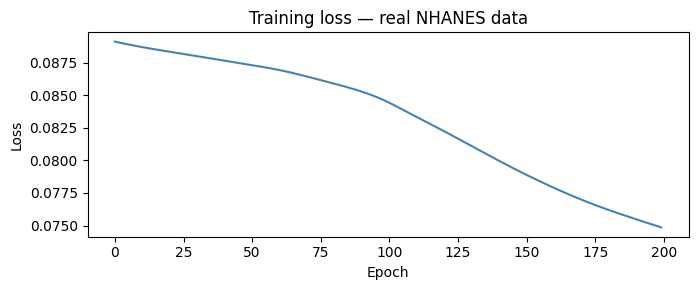

In [10]:
# 1. Build a neural network that compresses 10 features → 6-dim fingerprint
# 2. Encoder shrinks data to capture hidden patterns (not just raw numbers)
# 3. Decoder reconstructs original data — forces encoder to learn meaningful compression
# 4. Train for 200 epochs on your real 1000-person NHANES dataset

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

X = torch.tensor(df_scaled, dtype=torch.float32)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(10, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(6, 8),
            nn.ReLU(),
            nn.Linear(8, 10),
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(200):
    output, embedding = model(X)
    loss = loss_fn(output, X)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.5f}")
print(f"✅ Autoencoder trained on real data!")

plt.figure(figsize=(7,3))
plt.plot(losses, color='steelblue')
plt.title("Training loss — real NHANES data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [11]:
# 1. Pass all 1000 real people through the trained encoder → get their 6-dim fingerprints
# 2. Encode your own profile using the same encoder
# 3. Find top 5 most similar real people using learned embeddings (smarter than raw cosine)
# 4. These matches are now based on hidden biological patterns, not just surface numbers

with torch.no_grad():
    _, all_embeddings = model(X)
all_embeddings = all_embeddings.numpy()

new_user = pd.DataFrame([{
    'Age': 19,
    'BMI': 22.5,
    'Daily_Steps': 5000,
    'Hours_of_Sleep': 6.0,
    'Heart_Rate': 75,
    'Exercise_Hours_per_Week': 3.0,
    'Calories_Intake': 2000,
    'Weight_kg': 65,
    'Height_cm': 170,
    'Alcohol_Consumption_per_Week': 1
}])

new_user_scaled = scaler.transform(new_user)
new_user_tensor = torch.tensor(new_user_scaled, dtype=torch.float32)

with torch.no_grad():
    _, user_embedding = model(new_user_tensor)
user_embedding = user_embedding.numpy()

from sklearn.metrics.pairwise import cosine_similarity
sim_scores = cosine_similarity(user_embedding, all_embeddings)[0]
top5 = sim_scores.argsort()[-5:][::-1]

print("Top 5 similar profiles (learned embeddings):\n")
for rank, idx in enumerate(top5, 1):
    score = sim_scores[idx]
    person = df_clean.iloc[idx]
    print(f"Rank {rank} | Similarity: {score:.3f}")
    print(f"  Age:{person.Age}  BMI:{person.BMI}  Sleep:{person.Hours_of_Sleep}h  Steps:{person.Daily_Steps}")
    print()

Top 5 similar profiles (learned embeddings):

Rank 1 | Similarity: 0.998
  Age:29.0  BMI:30.09  Sleep:8.9h  Steps:6919.0

Rank 2 | Similarity: 0.997
  Age:25.0  BMI:30.85  Sleep:8.1h  Steps:1691.0

Rank 3 | Similarity: 0.996
  Age:44.0  BMI:27.06  Sleep:8.6h  Steps:6450.0

Rank 4 | Similarity: 0.996
  Age:19.0  BMI:33.78  Sleep:7.2h  Steps:14159.0

Rank 5 | Similarity: 0.994
  Age:29.0  BMI:32.33  Sleep:7.0h  Steps:9346.0



In [12]:
# 1. Run SHAP on the autoencoder using your real profile
# 2. Finds which of your 10 features drove the similarity matches
# 3. Prints ranked feature contributions with direction (increases/decreases)
# 4. This is your XAI layer — the "why" behind every match

import shap
import numpy as np

feature_names = list(df_clean.columns)

def model_predict(x):
    tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        _, emb = model(tensor)
    return cosine_similarity(emb.numpy(), user_embedding).flatten()

background = df_scaled[:100]
explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(new_user_scaled, nsamples=200)

print("Feature contribution to your similarity score:\n")
importance = list(zip(feature_names, shap_values[0]))
importance.sort(key=lambda x: abs(x[1]), reverse=True)
for feat, val in importance:
    direction = "↑ increases" if val > 0 else "↓ decreases"
    print(f"  {feat:30s} | {direction} similarity | SHAP: {val:+.4f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Feature contribution to your similarity score:

  Age                            | ↑ increases similarity | SHAP: +0.0369
  Calories_Intake                | ↑ increases similarity | SHAP: +0.0135
  Alcohol_Consumption_per_Week   | ↑ increases similarity | SHAP: +0.0124
  Daily_Steps                    | ↑ increases similarity | SHAP: +0.0120
  Height_cm                      | ↑ increases similarity | SHAP: +0.0113
  Weight_kg                      | ↑ increases similarity | SHAP: +0.0111
  Heart_Rate                     | ↑ increases similarity | SHAP: +0.0074
  Exercise_Hours_per_Week        | ↓ decreases similarity | SHAP: -0.0056
  Hours_of_Sleep                 | ↑ increases similarity | SHAP: +0.0045
  BMI                            | ↓ decreases similarity | SHAP: -0.0035


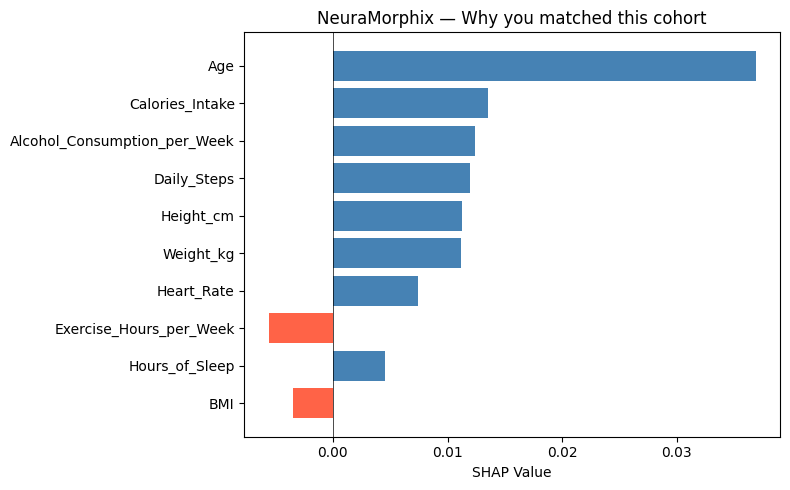

✅ Chart saved as shap_chart.png


In [13]:
# 1. Visualize SHAP values as a bar chart
# 2. Red = decreases similarity, Blue = increases similarity
# 3. This is the chart that goes on your product dashboard
# 4. Save it as an image for your GitHub README

features = [x[0] for x in importance]
values = [x[1] for x in importance]
colors = ['steelblue' if v > 0 else 'tomato' for v in values]

plt.figure(figsize=(8, 5))
plt.barh(features[::-1], values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel("SHAP Value")
plt.title("NeuraMorphix — Why you matched this cohort")
plt.tight_layout()
plt.savefig("shap_chart.png", dpi=150)
plt.show()

print("✅ Chart saved as shap_chart.png")

In [22]:
# 1. Reads API key safely from Colab Secrets — never exposed in code
# 2. Builds a prompt using your real SHAP values and similarity score
# 3. Sends to Gemini — returns a non-diagnostic insight paragraph
# 4. This is your LLM layer — the "why" explained in plain English

import google.generativeai as genai
from google.colab import userdata

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

top3_features = importance[:3]
shap_summary = ", ".join([
    f"{feat} ({'+' if val > 0 else ''}{val:.3f})"
    for feat, val in top3_features
])

similarity_score = sim_scores[top5[0]]

prompt = f"""
You are a biological pattern analyst. You do NOT diagnose diseases
or recommend treatments. You only provide awareness-based insights.

A user's biological profile was analyzed.
Their top similarity score with a matched cohort is {similarity_score:.3f} out of 1.0.
The features that most influenced this match are: {shap_summary}.

In 3-4 sentences, explain what these patterns suggest in simple,
non-diagnostic language. Use hedged phrases like
"patterns suggest", "similar profiles tend to", "you may want to explore".
Never mention any disease or medical condition.
"""

model_gemini = genai.GenerativeModel("gemini-2.5-flash")
response = model_gemini.generate_content(prompt)

print("NeuraMorphix Insight:\n")
print(response.text)

NeuraMorphix Insight:

Your biological profile demonstrates a remarkably high similarity to a specific matched cohort, indicating a strong alignment with their observed patterns. The patterns suggest that your age, daily caloric intake, and weekly alcohol consumption are key features contributing significantly to this resemblance. Similar profiles tend to share common lifestyle characteristics or biological trends related to these factors. You may want to explore how these particular aspects of your profile align with your personal well-being goals or daily habits for enhanced self-awareness.


In [23]:
# 1. Test 5 completely different user profiles
# 2. Each profile goes through full pipeline — similarity + SHAP + Gemini
# 3. Shows system generates different insights for different people
# 4. Proves NeuraMorphix is dynamic, not hardcoded

test_profiles = [
    {"Age": 19, "BMI": 22.5, "Daily_Steps": 5000, "Hours_of_Sleep": 6.0,
     "Heart_Rate": 75, "Exercise_Hours_per_Week": 3.0, "Calories_Intake": 2000,
     "Weight_kg": 65, "Height_cm": 170, "Alcohol_Consumption_per_Week": 1},

    {"Age": 45, "BMI": 32.0, "Daily_Steps": 2000, "Hours_of_Sleep": 5.0,
     "Heart_Rate": 90, "Exercise_Hours_per_Week": 1.0, "Calories_Intake": 2800,
     "Weight_kg": 95, "Height_cm": 168, "Alcohol_Consumption_per_Week": 5},

    {"Age": 28, "BMI": 19.5, "Daily_Steps": 12000, "Hours_of_Sleep": 8.0,
     "Heart_Rate": 60, "Exercise_Hours_per_Week": 6.0, "Calories_Intake": 1800,
     "Weight_kg": 58, "Height_cm": 172, "Alcohol_Consumption_per_Week": 0},

    {"Age": 60, "BMI": 27.0, "Daily_Steps": 3000, "Hours_of_Sleep": 7.0,
     "Heart_Rate": 80, "Exercise_Hours_per_Week": 2.0, "Calories_Intake": 2200,
     "Weight_kg": 78, "Height_cm": 165, "Alcohol_Consumption_per_Week": 2},

    {"Age": 22, "BMI": 24.0, "Daily_Steps": 8000, "Hours_of_Sleep": 9.0,
     "Heart_Rate": 68, "Exercise_Hours_per_Week": 4.0, "Calories_Intake": 2100,
     "Weight_kg": 70, "Height_cm": 175, "Alcohol_Consumption_per_Week": 1},
]

for i, profile in enumerate(test_profiles, 1):
    p_df = pd.DataFrame([profile])
    p_scaled = scaler.transform(p_df)
    p_tensor = torch.tensor(p_scaled, dtype=torch.float32)

    with torch.no_grad():
        _, p_emb = model(p_tensor)
    p_emb = p_emb.numpy()

    sims = cosine_similarity(p_emb, all_embeddings)[0]
    top_idx = sims.argsort()[-3:][::-1]
    top_score = sims[top_idx[0]]

    imp = list(zip(feature_names,
                   explainer.shap_values(p_scaled, nsamples=100)[0]))
    imp.sort(key=lambda x: abs(x[1]), reverse=True)
    shap_str = ", ".join([f"{f}({v:+.3f})" for f, v in imp[:3]])

    prompt = f"""
You are a biological pattern analyst. No diagnoses or treatments.
Similarity score: {top_score:.3f}. Top features: {shap_str}.
Give 2 sentences of non-diagnostic awareness insight.
Use hedged language. Never mention any disease.
"""
    resp = model_gemini.generate_content(prompt)

    print(f"Profile {i} | Age:{profile['Age']} BMI:{profile['BMI']} Sleep:{profile['Hours_of_Sleep']}h")
    print(f"Similarity: {top_score:.3f}")
    print(f"Insight: {resp.text.strip()}")
    print()

  0%|          | 0/1 [00:00<?, ?it/s]

Profile 1 | Age:19 BMI:22.5 Sleep:6.0h
Similarity: 0.998
Insight: The very high similarity score indicates a substantial presence of this particular biological pattern, with age appearing to be a prominent influencing factor. Additionally, lifestyle elements such as calorie intake and alcohol consumption per week may contribute to aspects of this observed pattern.



  0%|          | 0/1 [00:00<?, ?it/s]

Profile 2 | Age:45 BMI:32.0 Sleep:5.0h
Similarity: 1.000
Insight: This particular pattern of biological similarity appears to have a subtle association with reduced weekly exercise and fewer hours of sleep. There also seems to be a slight tendency for this pattern to be more noticeable with increasing age.



  0%|          | 0/1 [00:00<?, ?it/s]

...

Profile 3 | Age:28 BMI:19.5 Sleep:8.0h
Similarity: 0.999
Insight: The analysis indicates that higher reported weekly alcohol consumption appears to be a notable feature contributing to the identified biological patterns. Factors such as increasing age and greater height measurements also seem to contribute to these distinct patterns within the analyzed data.



  0%|          | 0/1 [00:00<?, ?it/s]

Profile 4 | Age:60 BMI:27.0 Sleep:7.0h
Similarity: 1.000
Insight: The perfect similarity score suggests that this particular biological pattern is prominently characterized by relatively lower levels of alcohol consumption and exercise, alongside comparatively higher caloric intake. Such a specific configuration of these lifestyle-related factors may offer a distinctive profile when evaluating the overall composition of this observed biological system state.



  0%|          | 0/1 [00:00<?, ?it/s]

Profile 5 | Age:22 BMI:24.0 Sleep:9.0h
Similarity: 0.999
Insight: This profile's biological patterns seem to show a strong alignment with others where relatively higher weekly alcohol consumption, advancing age, and greater height are among the more prominent differentiating characteristics. It could be noted that within highly similar biological patterns, these particular features might often be observed together.



In [24]:
# 1. Upgraded prompt — more structured, more useful output
# 2. Three sections: Pattern Summary, Key Drivers, Awareness Nudge
# 3. Feels like a real product insight card, not a research output
# 4. This is the exact format that goes on your React dashboard

def generate_insight(profile_dict):
    p_df = pd.DataFrame([profile_dict])
    p_scaled = scaler.transform(p_df)
    p_tensor = torch.tensor(p_scaled, dtype=torch.float32)

    with torch.no_grad():
        _, p_emb = model(p_tensor)
    p_emb = p_emb.numpy()

    sims = cosine_similarity(p_emb, all_embeddings)[0]
    top_idx = sims.argsort()[-5:][::-1]
    top_score = sims[top_idx[0]]

    imp = list(zip(feature_names,
                   explainer.shap_values(p_scaled, nsamples=100)[0]))
    imp.sort(key=lambda x: abs(x[1]), reverse=True)
    top3 = imp[:3]
    shap_str = ", ".join([f"{f} ({v:+.3f})" for f, v in top3])

    prompt = f"""
You are NeuraMorphix, a biological pattern awareness assistant.
You NEVER diagnose, predict disease, or recommend treatment.
You only provide pattern-based awareness insights.

User biological profile analysis:
- Cohort similarity score: {top_score:.3f} out of 1.0
- Top influential features: {shap_str}
- Profile: Age {profile_dict['Age']}, BMI {profile_dict['BMI']},
  Sleep {profile_dict['Hours_of_Sleep']}h,
  Steps {profile_dict['Daily_Steps']}/day

Respond in exactly this format:

PATTERN SUMMARY:
[1 sentence — what the overall similarity pattern suggests]

KEY DRIVERS:
[1 sentence — which features are driving the match and how]

AWARENESS NUDGE:
[1 sentence — one non-medical lifestyle reflection the user may explore]
"""

    resp = model_gemini.generate_content(prompt)
    return top_score, resp.text.strip()

# Test with your own profile
my_profile = {
    "Age": 19, "BMI": 22.5, "Daily_Steps": 5000,
    "Hours_of_Sleep": 6.0, "Heart_Rate": 75,
    "Exercise_Hours_per_Week": 3.0, "Calories_Intake": 2000,
    "Weight_kg": 65, "Height_cm": 170,
    "Alcohol_Consumption_per_Week": 1
}

score, insight = generate_insight(my_profile)
print(f"Similarity: {score:.3f}\n")
print(insight)

  0%|          | 0/1 [00:00<?, ?it/s]

Similarity: 0.998

PATTERN SUMMARY:
Your biological profile demonstrates an exceptionally high congruence with a specific pattern observed within the analyzed cohort.

KEY DRIVERS:
The strong alignment is predominantly influenced by your age, caloric intake, and height, which are key distinguishing features within this matching pattern.

AWARENESS NUDGE:
Reflecting on how your current sleep duration consistently interacts with your perceived daily energy levels could offer insightful personal awareness.
